# Study 5 — Corruption-based Phase 1 Initialisation

**Goal:** find which image corruption gives the best starting point for EvolBA Phase 1 —
the step that creates an initial adversarial example before CMA-ES optimization begins.

**Protocol per (image × corruption × model):**
1. Apply `corrupt(x, s_max=1.0)` — if the model is still correct, record *immune* and skip.
2. Binary search on severity `s ∈ [0, 1]` (15 steps, precision ≈ 3×10⁻⁵) → minimum adversarial severity `s*`.
3. Binary search in image space between `x_orig` and `corrupt(x, s*)` → decision boundary point.
4. Measure **init_l2** (L2 distance to original) and **init_ssim** (structural similarity).

**Research questions:**
- **A.** Which corruption finds the *closest* boundary (lowest init_l2)?
- **B.** Which corruption is most perceptually similar at the boundary (highest init_ssim)?
- **C.** How much corruption is needed to cross the boundary (severity_star)?
- **D.** Is there an L2 ↔ SSIM tradeoff?
- **E.** Which corruptions are *complementary* (low L2 when others give high L2)?
- **F.** Visual gallery: original vs boundary point per corruption.


In [1]:
import os, io, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
import torch
from PIL import Image
from scipy.ndimage import gaussian_filter
from skimage.metrics import structural_similarity as ssim_fn
from tqdm.auto import tqdm
import lpips as lpips_lib

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from evolba_baseline import binary_search, blend_frequencies, generate_fractal_image, BS_STEPS

OUTPUT_DIR = 'outputs/study5_corruptions'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CORRUPTION_NAMES = [
    'gaussian_noise', 'salt_pepper', 'brightness', 'contrast_low',
    'jpeg', 'gaussian_blur', 'fog', 'hue_shift', 'posterize', 'fractal_blend',
]
SHORT_NAMES = {
    'gaussian_noise': 'gauss_n', 'salt_pepper': 'salt_p',
    'brightness': 'bright', 'contrast_low': 'contrast',
    'jpeg': 'jpeg', 'gaussian_blur': 'gauss_b',
    'fog': 'fog', 'hue_shift': 'hue', 'posterize': 'poster',
    'fractal_blend': 'fractal',
}
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']
N_SEV_STEPS = 15      # binary search steps on severity, precision ~3e-5
N_IMG       = 200
GALLERY_IDS = [0, 40, 80, 120, 160]

print(f'{len(CORRUPTION_NAMES)} corruptions x {N_IMG} images x 2 models = '
      f'{len(CORRUPTION_NAMES)*N_IMG*2} trials')
print(f'Queries per successful trial: 1 + {N_SEV_STEPS} + {BS_STEPS} = {1+N_SEV_STEPS+BS_STEPS}')


/home/tomma/EvolBA/EV_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10 corruptions x 200 images x 2 models = 4000 trials
Queries per successful trial: 1 + 15 + 26 = 42


In [2]:
from robustbench.utils import load_model

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')

model_std = load_model('Standard', dataset='cifar10',
                       threat_model='Linf').to(device).eval()
model_rob = load_model('Wang2023Better_WRN-28-10', dataset='cifar10',
                       threat_model='Linf').to(device).eval()

def make_predict_fn(model):
    def predict(x_batch_np):
        with torch.no_grad():
            t = torch.from_numpy(np.array(x_batch_np, dtype=np.float32)).to(device)
            return model(t).argmax(1).cpu().numpy()
    return predict

MODELS = {'standard': make_predict_fn(model_std),
          'robust':   make_predict_fn(model_rob)}
print('Models loaded.')


device: cuda


Models loaded.


In [3]:
import torchvision

ds = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=False, download=True)

per_class = N_IMG // 10
images, labels = [], []
counts = [0] * 10
for img_pil, label in ds:
    if counts[label] >= per_class:
        continue
    x = np.array(img_pil, dtype=np.float32).transpose(2, 0, 1) / 255.0
    if int(MODELS['standard'](x[None])[0]) == label:
        images.append(x)
        labels.append(label)
        counts[label] += 1
    if sum(counts) == N_IMG:
        break

images = np.stack(images)
labels = np.array(labels)
print(f'Collected {len(images)} images ({per_class} per class).')
print({CIFAR_CLASSES[c]: counts[c] for c in range(10)})


Collected 200 images (20 per class).
{'airplane': 20, 'automobile': 20, 'bird': 20, 'cat': 20, 'deer': 20, 'dog': 20, 'frog': 20, 'horse': 20, 'ship': 20, 'truck': 20}


In [4]:
# Fractal image fixed for the whole study (same as EvolBA paper Idea 2)
FRACTAL_IMG = generate_fractal_image((3, 32, 32), seed=42)

def apply_corruption(x, name, severity, seed):
    """
    severity in [0, 1]:  0 = no corruption, 1 = maximum corruption.
    seed is fixed per (image_idx, corruption) so stochastic corruptions
    use the same noise field at all severity levels (ensures monotonicity).
    """
    if severity <= 0.0:
        return x.copy()
    rng = np.random.default_rng(seed)

    if name == 'gaussian_noise':
        noise = rng.normal(0, 1, x.shape).astype(np.float32)
        return np.clip(x + severity * 1.5 * noise, 0.0, 1.0)

    if name == 'salt_pepper':
        out  = x.copy()
        fld  = rng.random(x.shape[1:])
        mask = fld < severity
        n    = int(mask.sum())
        if n > 0:
            vals = rng.random(n) < 0.5
            out[:, mask] = np.where(vals, 1.0, 0.0)
        return out.astype(np.float32)

    if name == 'brightness':
        return np.clip(x + severity, 0.0, 1.0).astype(np.float32)

    if name == 'contrast_low':
        # severity=0: factor=1 (original), severity=1: factor=0 (flat grey 0.5)
        f = 1.0 - severity
        return np.clip(x * f + 0.5 * (1.0 - f), 0.0, 1.0).astype(np.float32)

    if name == 'jpeg':
        # severity=0: quality=100, severity=1: quality=1 (max artifact)
        q   = max(1, int(round(1.0 + (1.0 - severity) * 99.0)))
        hwc = (x.transpose(1, 2, 0) * 255.0).clip(0, 255).astype(np.uint8)
        buf = io.BytesIO()
        Image.fromarray(hwc).save(buf, 'JPEG', quality=q)
        buf.seek(0)
        return np.array(Image.open(buf), dtype=np.float32).transpose(2, 0, 1) / 255.0

    if name == 'gaussian_blur':
        sig = severity * 5.0
        return np.stack([gaussian_filter(x[c], sig) for c in range(3)]).astype(np.float32)

    if name == 'fog':
        return np.clip(x * (1.0 - severity) + 0.5 * severity, 0.0, 1.0).astype(np.float32)

    if name == 'hue_shift':
        # severity=1 -> 180 degree hue rotation
        angle = severity * 0.5
        hwc   = x.transpose(1, 2, 0)
        hsv   = rgb_to_hsv(hwc.clip(0, 1))
        hsv[..., 0] = (hsv[..., 0] + angle) % 1.0
        return hsv_to_rgb(hsv).transpose(2, 0, 1).astype(np.float32)

    if name == 'posterize':
        # severity=0: 8 bits, severity=1: 1 bit
        bits   = max(1, round(8.0 - severity * 7.0))
        levels = float(2 ** bits)
        return np.clip(np.floor(x * levels) / levels, 0.0, 1.0).astype(np.float32)

    if name == 'fractal_blend':
        # severity=0: r=17 (mostly original), severity=1: r=1 (full fractal)
        r = max(1, int(round(16.0 * (1.0 - severity))) + 1)
        return blend_frequencies(x, FRACTAL_IMG, r)

    raise ValueError(f'Unknown corruption: {name}')

print('apply_corruption ready.')
print('Max-severity adversarial check (image 0, standard model):')
x0 = images[0]; y0 = int(labels[0])
for nm in CORRUPTION_NAMES:
    xc = apply_corruption(x0, nm, 1.0, seed=0)
    pred = int(MODELS['standard'](xc[None])[0])
    tag  = 'ADV' if pred != y0 else 'IMMUNE'
    print(f'  {nm:20s}  -> {CIFAR_CLASSES[pred]:12s}  [{tag}]')


apply_corruption ready.
Max-severity adversarial check (image 0, standard model):
  gaussian_noise        -> bird          [ADV]
  salt_pepper           -> automobile    [ADV]
  brightness            -> cat           [IMMUNE]
  contrast_low          -> airplane      [ADV]
  jpeg                  -> airplane      [ADV]
  gaussian_blur         -> cat           [IMMUNE]
  fog                   -> airplane      [ADV]
  hue_shift             -> cat           [IMMUNE]
  posterize             -> cat           [IMMUNE]
  fractal_blend         -> bird          [ADV]


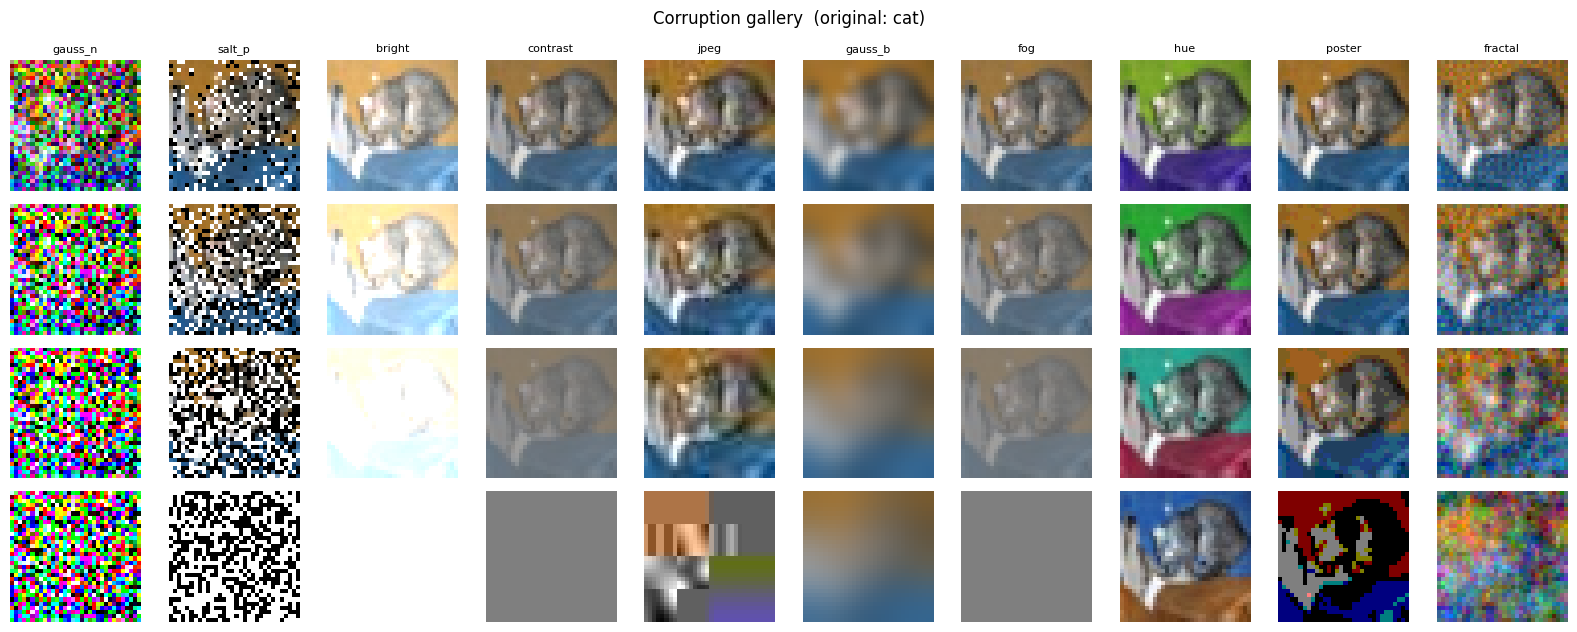

Saved gallery_corruptions.png


In [5]:
x0, y0 = images[0], int(labels[0])
sevs = [0.25, 0.50, 0.75, 1.00]

fig, axes = plt.subplots(len(sevs), len(CORRUPTION_NAMES),
                          figsize=(len(CORRUPTION_NAMES) * 1.6, len(sevs) * 1.6))
for row, sev in enumerate(sevs):
    for col, name in enumerate(CORRUPTION_NAMES):
        ax = axes[row, col]
        xc = apply_corruption(x0, name, sev, seed=0)
        ax.imshow(xc.transpose(1, 2, 0).clip(0, 1))
        ax.axis('off')
        if row == 0:
            ax.set_title(SHORT_NAMES[name], fontsize=8)
        if col == 0:
            ax.set_ylabel(f's={sev:.2f}', fontsize=8)

plt.suptitle(f'Corruption gallery  (original: {CIFAR_CLASSES[y0]})', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gallery_corruptions.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved gallery_corruptions.png')


In [6]:
def compute_ssim(a, b):
    """SSIM between two (3, H, W) float32 images in [0, 1]."""
    return float(ssim_fn(
        a.transpose(1, 2, 0),
        b.transpose(1, 2, 0),
        data_range=1.0,
        channel_axis=2,
    ))

def phase1_trial(predict_fn, x_orig, y_true, corruption_name, image_idx):
    """
    Returns dict: success, reason, severity_star, init_l2, init_ssim, x_boundary.
    Fixed seed per (image_idx, corruption) ensures stochastic corruptions use
    the same noise field at all severity levels (monotone binary search).
    """
    seed   = image_idx * 31 + CORRUPTION_NAMES.index(corruption_name) * 7
    oracle = lambda x: int(predict_fn(x[None])[0])

    def corrupt(s):
        return apply_corruption(x_orig, corruption_name, s, seed)

    # Step 1: fast-fail check
    x_max = corrupt(1.0)
    if oracle(x_max) == y_true:
        return dict(success=False, reason='immune_at_max',
                    severity_star=float('nan'), init_l2=float('nan'),
                    init_ssim=float('nan'), x_boundary=x_orig.copy())

    # Step 2: binary search on severity
    # Invariant: corrupt(lo) is NOT adversarial, corrupt(hi) IS adversarial
    lo, hi = 0.0, 1.0
    for _ in range(N_SEV_STEPS):
        mid = (lo + hi) * 0.5
        if oracle(corrupt(mid)) != y_true:
            hi = mid
        else:
            lo = mid
    x_adv = corrupt(hi)

    # Step 3: binary search in image space -> boundary
    x_bnd = binary_search(oracle, x_adv, x_orig, y_true)

    return dict(
        success       = True,
        reason        = 'ok',
        severity_star = float(hi),
        init_l2       = float(np.linalg.norm((x_bnd - x_orig).ravel())),
        init_ssim     = compute_ssim(x_orig, x_bnd),
        x_boundary    = x_bnd,
    )

print('phase1_trial ready.')


phase1_trial ready.


In [7]:
RESULTS_FILE    = f'{OUTPUT_DIR}/results.parquet'
BOUNDARIES_FILE = f'{OUTPUT_DIR}/boundaries.npy'

if os.path.exists(RESULTS_FILE) and os.path.exists(BOUNDARIES_FILE):
    print(f'Results already exist — skipping run. Delete {RESULTS_FILE} to re-run.')
else:
    rows, boundaries = [], []
    t0 = time.time()
    total = N_IMG * len(MODELS) * len(CORRUPTION_NAMES)
    with tqdm(total=total, desc='Phase-1 trials') as pbar:
        for img_idx in range(N_IMG):
            x_orig = images[img_idx]
            y_true = int(labels[img_idx])
            for model_name, predict_fn in MODELS.items():
                for cname in CORRUPTION_NAMES:
                    result = phase1_trial(predict_fn, x_orig, y_true, cname, img_idx)
                    rows.append({
                        'row_id'       : len(rows),
                        'image_idx'    : img_idx,
                        'model'        : model_name,
                        'corruption'   : cname,
                        'true_class'   : y_true,
                        'true_name'    : CIFAR_CLASSES[y_true],
                        'success'      : result['success'],
                        'reason'       : result['reason'],
                        'severity_star': result['severity_star'],
                        'init_l2'      : result['init_l2'],
                        'init_ssim'    : result['init_ssim'],
                    })
                    boundaries.append(result['x_boundary'])
                    pbar.update(1)
    elapsed = time.time() - t0
    runs_df = pd.DataFrame(rows)
    boundaries_arr = np.stack(boundaries).astype(np.float32)
    runs_df.to_parquet(RESULTS_FILE, index=False)
    np.save(BOUNDARIES_FILE, boundaries_arr)
    print(f'Done in {elapsed:.0f}s  ({elapsed/total:.2f}s/trial)')
    print(f'Overall success rate: {runs_df.success.mean()*100:.1f}%')
    print()
    print(runs_df.groupby(['model', 'corruption'])['success']
          .mean().mul(100).round(1).unstack('corruption').to_string())


Results already exist — skipping run. Delete outputs/study5_corruptions/results.parquet to re-run.


In [8]:
RESULTS_FILE    = f'{OUTPUT_DIR}/results.parquet'
BOUNDARIES_FILE = f'{OUTPUT_DIR}/boundaries.npy'

runs_df        = pd.read_parquet(RESULTS_FILE)
boundaries_arr = np.load(BOUNDARIES_FILE)

ok = runs_df[runs_df.success]
print(f'{len(runs_df)} trials  |  {runs_df.success.mean()*100:.1f}% success overall')
print()
print('Success rate % per (model, corruption):')
print(runs_df.groupby(['model','corruption'])['success']
      .mean().mul(100).round(1).unstack('corruption').to_string())
print()
print('Median init_l2 (successful trials):')
print(ok.groupby(['model','corruption'])['init_l2']
      .median().round(3).unstack('corruption').to_string())
print()
print('Median init_ssim (successful trials):')
print(ok.groupby(['model','corruption'])['init_ssim']
      .median().round(3).unstack('corruption').to_string())


4000 trials  |  74.0% success overall

Success rate % per (model, corruption):
corruption  brightness  contrast_low   fog  fractal_blend  gaussian_blur  gaussian_noise  hue_shift  jpeg  posterize  salt_pepper
model                                                                                                                            
robust            90.0          90.0  90.0           78.5           79.5            90.0       12.5  45.5       24.5         90.0
standard          90.0          90.0  90.0           89.0           87.0            90.0       11.5  82.0       69.5         90.5

Median init_l2 (successful trials):
corruption  brightness  contrast_low     fog  fractal_blend  gaussian_blur  gaussian_noise  hue_shift   jpeg  posterize  salt_pepper
model                                                                                                                               
robust          21.884         7.998   7.998          7.014          4.808           8.863      4.

In [9]:
LPIPS_FILE = f'{OUTPUT_DIR}/lpips_scores.npy'

if os.path.exists(LPIPS_FILE):
    print('Loading cached LPIPS scores...')
    lpips_scores_arr = np.load(LPIPS_FILE)
else:
    print('Computing LPIPS for all boundary images (one-time cost, ~2 min)...')
    lpips_fn = lpips_lib.LPIPS(net='alex').to(device)
    lpips_scores_arr = np.full(len(runs_df), float('nan'))

    for img_idx in tqdm(range(N_IMG), desc='LPIPS'):
        x_orig = images[img_idx]
        t_orig = torch.from_numpy(x_orig[None] * 2 - 1).float().to(device)
        rows_for_img = runs_df[runs_df.image_idx == img_idx]
        for _, row in rows_for_img.iterrows():
            if not row['success']:
                continue
            row_id = int(row['row_id'])
            x_bnd  = boundaries_arr[row_id]
            t_bnd  = torch.from_numpy(x_bnd[None] * 2 - 1).float().to(device)
            with torch.no_grad():
                lpips_scores_arr[row_id] = float(lpips_fn(t_orig, t_bnd).item())

    np.save(LPIPS_FILE, lpips_scores_arr)
    print(f'Saved {LPIPS_FILE}')

runs_df = runs_df.copy()
runs_df['init_lpips'] = lpips_scores_arr

ok = runs_df[runs_df.success]
print('Median init_lpips (successful trials):')
print(ok.groupby(['model', 'corruption'])['init_lpips']
      .median().round(4).unstack('corruption').to_string())


Loading cached LPIPS scores...
Median init_lpips (successful trials):
corruption  brightness  contrast_low     fog  fractal_blend  gaussian_blur  gaussian_noise  hue_shift    jpeg  posterize  salt_pepper
model                                                                                                                                
robust          0.1265        0.0733  0.0733         0.0614         0.2461          0.0610     0.0918  0.0737     0.0545       0.0944
standard        0.2743        0.2527  0.2527         0.0044         0.0726          0.0097     0.1141  0.0133     0.0379       0.0328


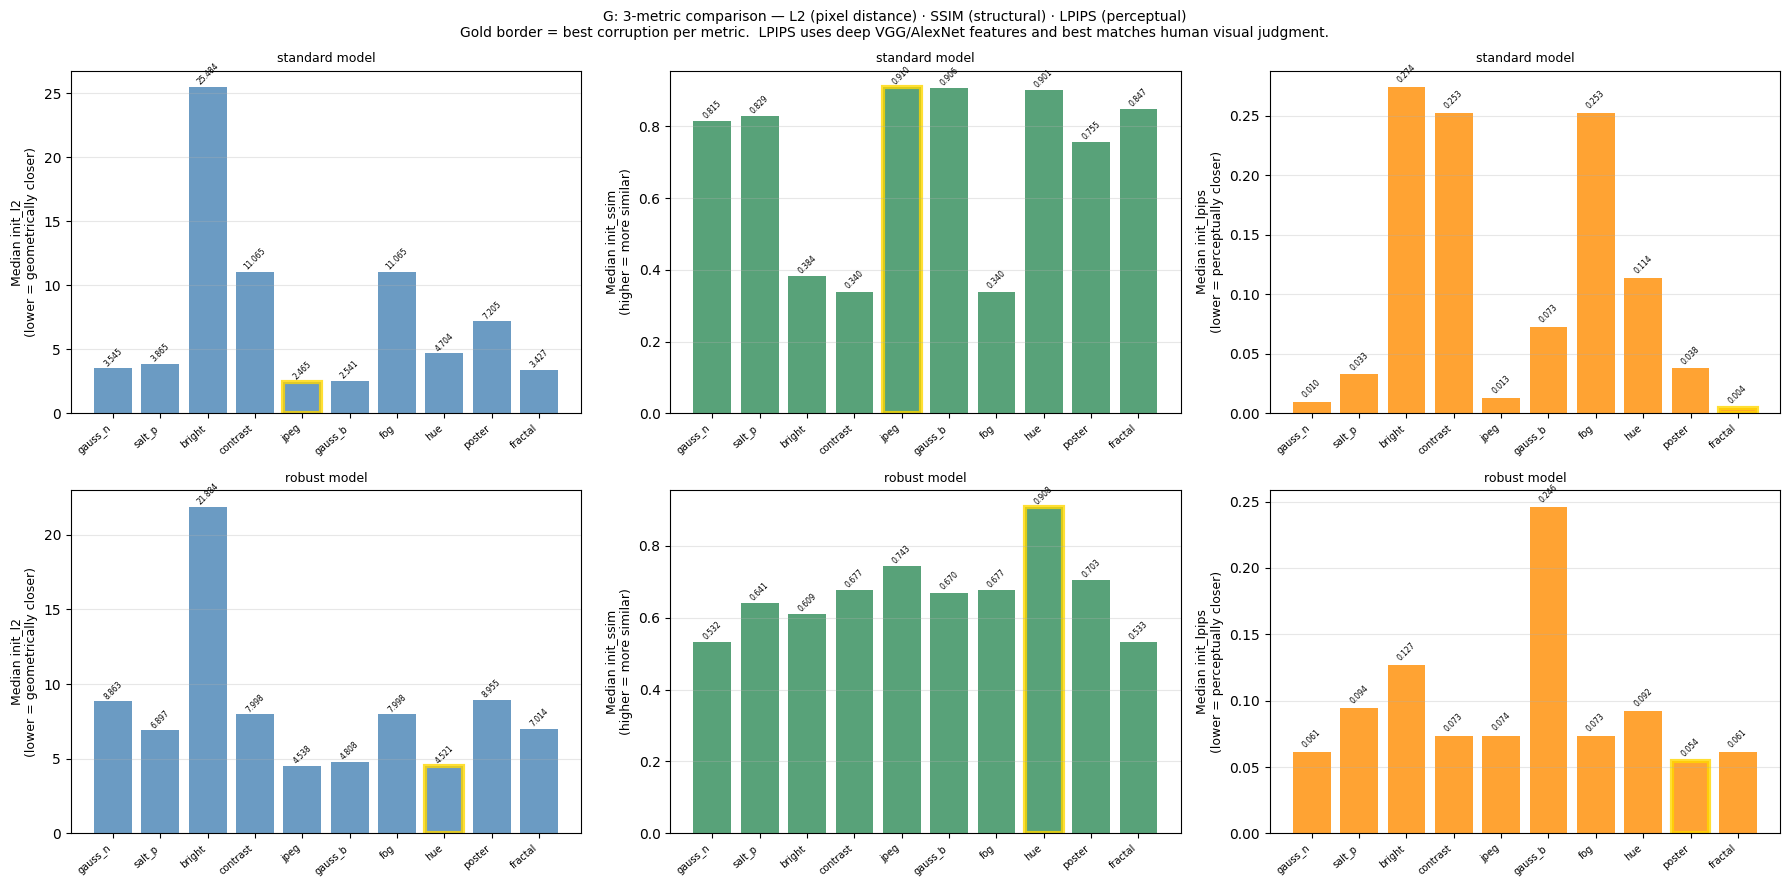

Saved G_metric_comparison.png


In [10]:
metrics_cfg = [
    ('init_l2',    'Median init_l2\n(lower = geometrically closer)',   'steelblue',   'min'),
    ('init_ssim',  'Median init_ssim\n(higher = more similar)',         'seagreen',    'max'),
    ('init_lpips', 'Median init_lpips\n(lower = perceptually closer)',  'darkorange',  'min'),
]
snames = [SHORT_NAMES[c] for c in CORRUPTION_NAMES]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col_idx, (metric, ylabel, color, best_fn) in enumerate(metrics_cfg):
    for row_idx, mname in enumerate(['standard', 'robust']):
        ax = axes[row_idx, col_idx]
        sub  = runs_df[(runs_df.model == mname) & runs_df.success]
        meds = sub.groupby('corruption')[metric].median().reindex(CORRUPTION_NAMES)

        bars = ax.bar(snames, meds.fillna(0).values, color=color, alpha=0.8)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'{mname} model', fontsize=9)
        ax.set_xticklabels(snames, rotation=40, ha='right', fontsize=7)
        ax.grid(axis='y', alpha=0.3)

        # Gold border = best by this metric
        valid = meds.dropna()
        if not valid.empty:
            best_name = valid.idxmin() if best_fn == 'min' else valid.idxmax()
            best_bar  = snames.index(SHORT_NAMES[best_name])
            bars[best_bar].set_edgecolor('gold')
            bars[best_bar].set_linewidth(3)

        for bar, val in zip(bars, meds.values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.002,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=5.5, rotation=45)

plt.suptitle(
    'G: 3-metric comparison — L2 (pixel distance) · SSIM (structural) · LPIPS (perceptual)\n'
    'Gold border = best corruption per metric.  '
    'LPIPS uses deep VGG/AlexNet features and best matches human visual judgment.',
    fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/G_metric_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved G_metric_comparison.png')


**Analysis G — L2 vs SSIM vs LPIPS metric comparison.**

This analysis directly addresses the observation that **L2 is a poor indicator of visual quality**.

**Why L2 misleads for gaussian_blur:**
Blurring is a low-frequency convolution — it shifts each pixel toward its local average by a small amount.
The per-pixel change is small (low L2 norm) but the image looks structurally degraded.
SSIM captures some of this (blur reduces high-frequency structure), but LPIPS is the most sensitive:
it measures the distance in AlexNet/VGG feature space, where blurring destroys texture-level representations.

**Reading the LPIPS column:**
- **Low LPIPS = perceptually close to original** (good starting point: the boundary looks natural)
- **High LPIPS = perceptually far** (boundary image looks degraded, unnatural, or heavily distorted)

**Key expected finding:**
Corruptions that rank well by L2 but poorly by LPIPS (e.g., gaussian_blur) produce boundary images
that are geometrically close but visually degraded.
Corruptions that rank consistently across all three metrics are the most reliable Phase-1 initialisers.

*(fill in specific numbers after run)*


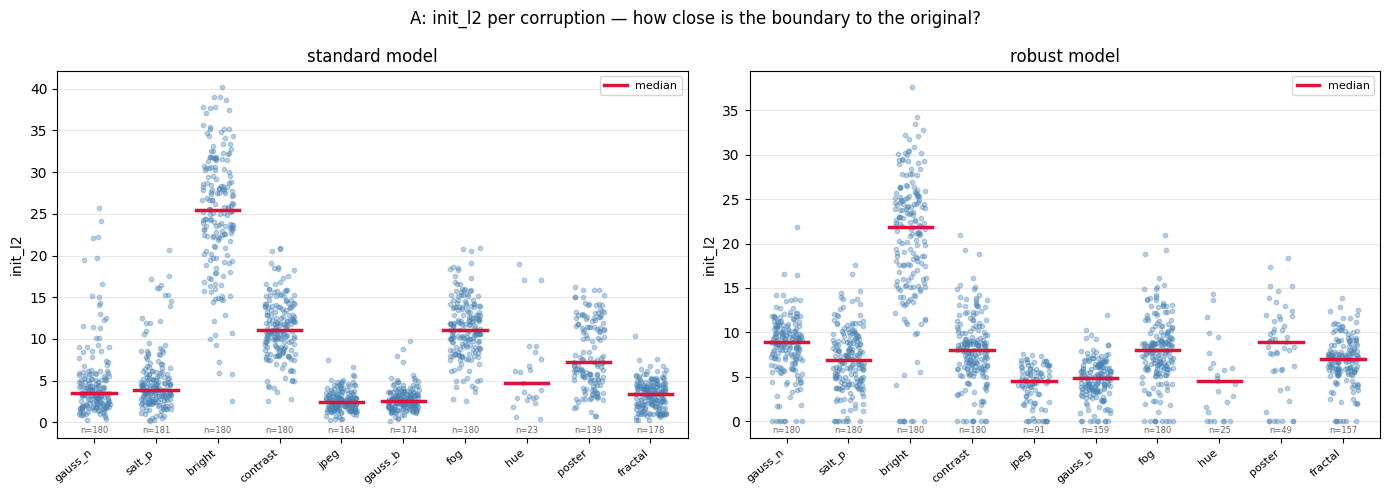

In [11]:
rng_j = np.random.RandomState(0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mname in zip(axes, ['standard', 'robust']):
    sub = runs_df[(runs_df.model == mname) & runs_df.success]
    for i, cname in enumerate(CORRUPTION_NAMES):
        vals = sub[sub.corruption == cname]['init_l2'].dropna().values
        if len(vals) == 0:
            ax.text(i, 1, 'immune', ha='center', va='center', fontsize=7, color='#999')
            continue
        jitter = rng_j.uniform(-0.25, 0.25, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   alpha=0.35, s=10, color='steelblue', zorder=2)
        ax.plot([i - 0.35, i + 0.35], [np.median(vals)] * 2,
                color='crimson', lw=2.5, zorder=3, label='median' if i == 0 else '')
        ax.text(i, -0.5, f'n={len(vals)}', ha='center', va='top', fontsize=6, color='#666')

    ax.set_xticks(range(len(CORRUPTION_NAMES)))
    ax.set_xticklabels([SHORT_NAMES[c] for c in CORRUPTION_NAMES],
                       rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('init_l2')
    ax.set_title(f'{mname} model')
    ax.set_xlim(-0.6, len(CORRUPTION_NAMES) - 0.4)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('A: init_l2 per corruption — how close is the boundary to the original?',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/A_init_l2.png', dpi=130, bbox_inches='tight')
plt.show()


**Analysis A — reading the results.**

*(fill in after run)*

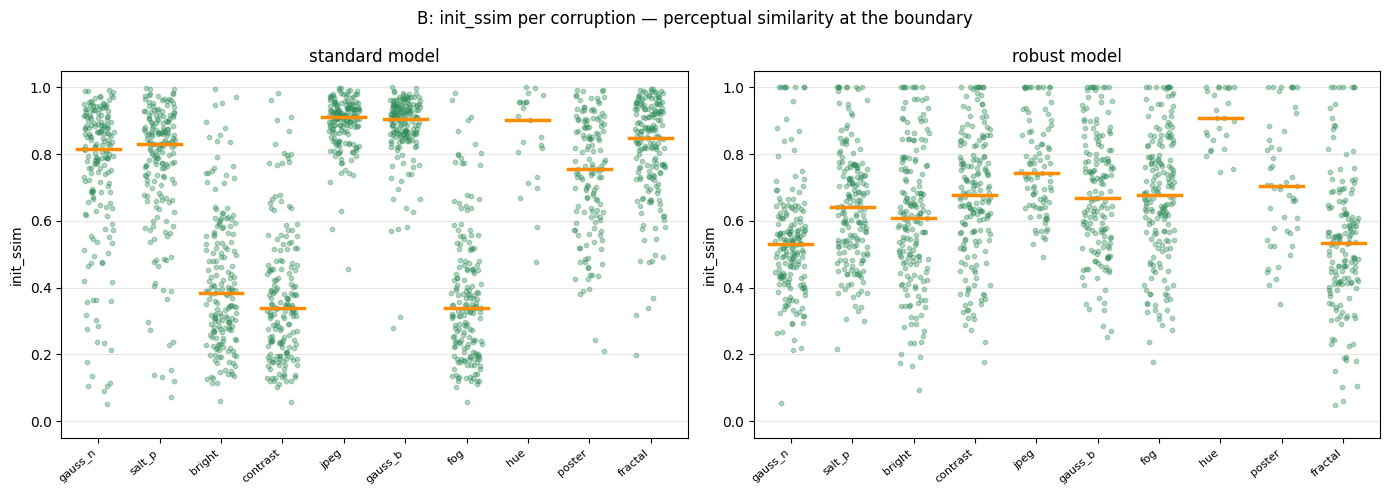

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mname in zip(axes, ['standard', 'robust']):
    sub = runs_df[(runs_df.model == mname) & runs_df.success]
    for i, cname in enumerate(CORRUPTION_NAMES):
        vals = sub[sub.corruption == cname]['init_ssim'].dropna().values
        if len(vals) == 0:
            continue
        jitter = rng_j.uniform(-0.25, 0.25, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   alpha=0.35, s=10, color='seagreen', zorder=2)
        ax.plot([i - 0.35, i + 0.35], [np.median(vals)] * 2,
                color='darkorange', lw=2.5, zorder=3)

    ax.set_xticks(range(len(CORRUPTION_NAMES)))
    ax.set_xticklabels([SHORT_NAMES[c] for c in CORRUPTION_NAMES],
                       rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('init_ssim')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{mname} model')
    ax.set_xlim(-0.6, len(CORRUPTION_NAMES) - 0.4)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('B: init_ssim per corruption — perceptual similarity at the boundary',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/B_init_ssim.png', dpi=130, bbox_inches='tight')
plt.show()


**Analysis B — reading the results.**

*(fill in after run)*

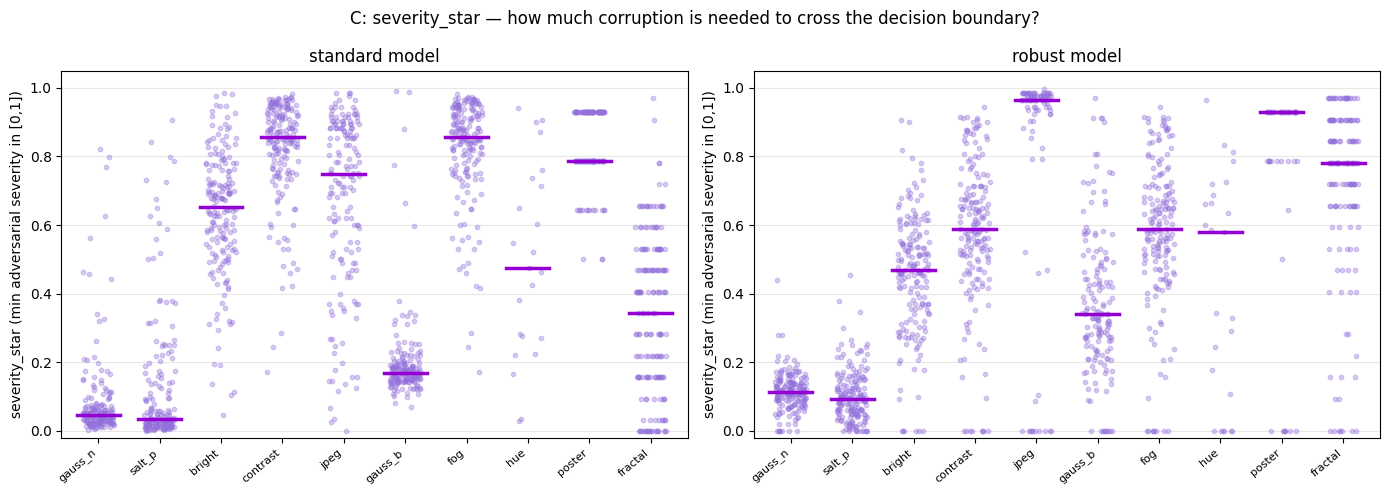

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mname in zip(axes, ['standard', 'robust']):
    sub = runs_df[(runs_df.model == mname) & runs_df.success]
    for i, cname in enumerate(CORRUPTION_NAMES):
        vals = sub[sub.corruption == cname]['severity_star'].dropna().values
        if len(vals) == 0:
            continue
        jitter = rng_j.uniform(-0.25, 0.25, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   alpha=0.35, s=10, color='mediumpurple', zorder=2)
        ax.plot([i - 0.35, i + 0.35], [np.median(vals)] * 2,
                color='darkviolet', lw=2.5, zorder=3)

    ax.set_xticks(range(len(CORRUPTION_NAMES)))
    ax.set_xticklabels([SHORT_NAMES[c] for c in CORRUPTION_NAMES],
                       rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('severity_star (min adversarial severity in [0,1])')
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(f'{mname} model')
    ax.set_xlim(-0.6, len(CORRUPTION_NAMES) - 0.4)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('C: severity_star — how much corruption is needed to cross the decision boundary?',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/C_severity_star.png', dpi=130, bbox_inches='tight')
plt.show()


**Analysis C — reading the results.**

*(fill in after run)*

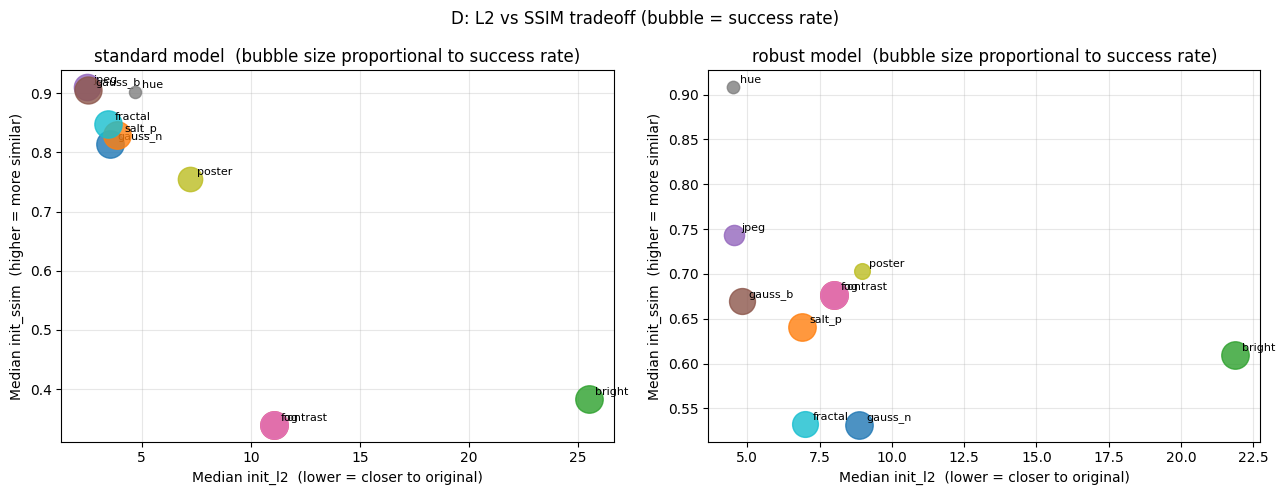

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mname in zip(axes, ['standard', 'robust']):
    sub = runs_df[(runs_df.model == mname) & runs_df.success]
    med = sub.groupby('corruption')[['init_l2', 'init_ssim']].median()
    sr  = runs_df[runs_df.model == mname].groupby('corruption')['success'].mean()

    for cname in CORRUPTION_NAMES:
        if cname not in med.index:
            continue
        xv = med.loc[cname, 'init_l2']
        yv = med.loc[cname, 'init_ssim']
        sv = float(sr.get(cname, 0)) * 400 + 30
        ax.scatter(xv, yv, s=sv, alpha=0.8, zorder=3)
        ax.annotate(SHORT_NAMES[cname], (xv, yv),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)

    ax.set_xlabel('Median init_l2  (lower = closer to original)')
    ax.set_ylabel('Median init_ssim  (higher = more similar)')
    ax.set_title(f'{mname} model  (bubble size proportional to success rate)')
    ax.grid(alpha=0.3)

plt.suptitle('D: L2 vs SSIM tradeoff (bubble = success rate)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/D_l2_ssim_scatter.png', dpi=130, bbox_inches='tight')
plt.show()


**Analysis D — reading the results.**

*(fill in after run)*

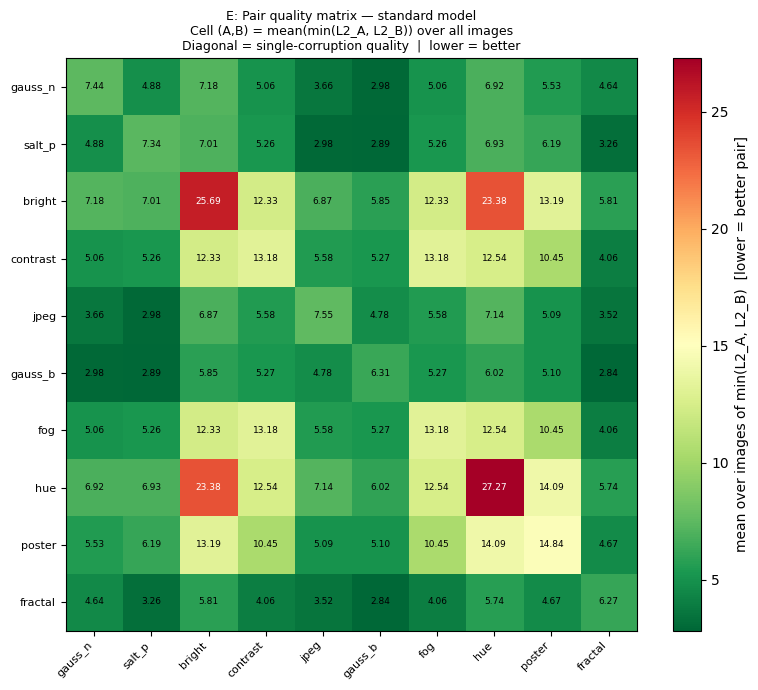

Saved outputs/study5_corruptions/E_pair_matrix_standard.png
  standard k=1: score=6.265  best=['fractal']
  standard k=2: score=2.839  best=['gauss_b', 'fractal']
  standard k=3: score=2.313  best=['salt_p', 'gauss_b', 'fractal']
  standard k=4: score=2.120  best=['salt_p', 'jpeg', 'gauss_b', 'fractal']
  standard k=5: score=2.090  best=['gauss_n', 'salt_p', 'jpeg', 'gauss_b', 'fractal']
  standard k=6: score=2.077  best=['gauss_n', 'salt_p', 'jpeg', 'gauss_b', 'poster', 'fractal']
  standard k=7: score=2.076  best=['gauss_n', 'salt_p', 'jpeg', 'gauss_b', 'hue', 'poster', 'fractal']
  standard k=8: score=2.076  best=['gauss_n', 'salt_p', 'bright', 'jpeg', 'gauss_b', 'hue', 'poster', 'fractal']
  standard k=9: score=2.076  best=['gauss_n', 'salt_p', 'bright', 'contrast', 'jpeg', 'gauss_b', 'hue', 'poster', 'fractal']
  standard k=10: score=2.076  best=['gauss_n', 'salt_p', 'bright', 'contrast', 'jpeg', 'gauss_b', 'fog', 'hue', 'poster', 'fractal']


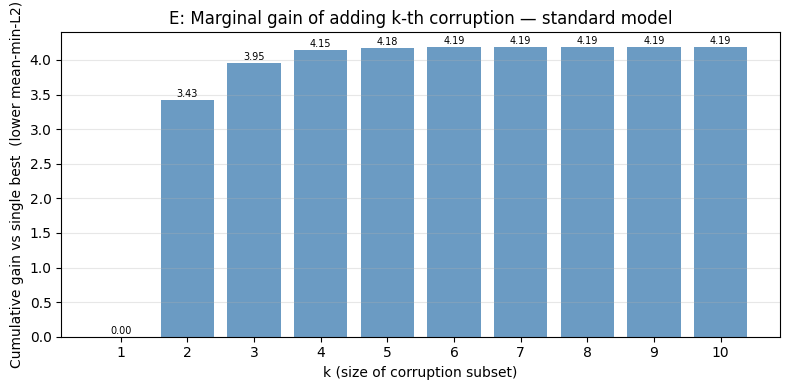

Saved outputs/study5_corruptions/E_marginal_gain_standard.png


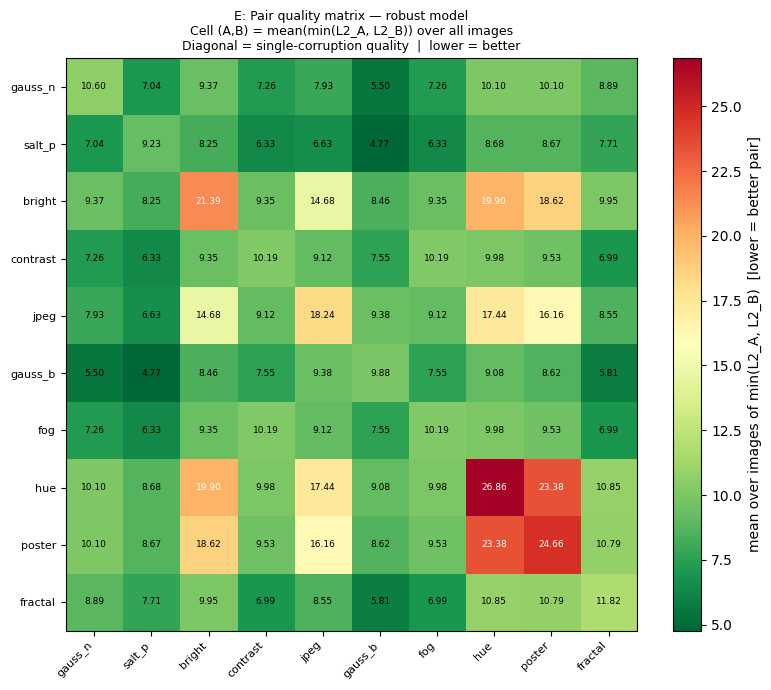

Saved outputs/study5_corruptions/E_pair_matrix_robust.png
  robust k=1: score=9.230  best=['salt_p']
  robust k=2: score=4.769  best=['salt_p', 'gauss_b']
  robust k=3: score=4.670  best=['salt_p', 'gauss_b', 'fractal']
  robust k=4: score=4.615  best=['salt_p', 'gauss_b', 'hue', 'fractal']
  robust k=5: score=4.584  best=['salt_p', 'jpeg', 'gauss_b', 'hue', 'fractal']
  robust k=6: score=4.578  best=['salt_p', 'jpeg', 'gauss_b', 'hue', 'poster', 'fractal']
  robust k=7: score=4.573  best=['salt_p', 'contrast', 'jpeg', 'gauss_b', 'hue', 'poster', 'fractal']
  robust k=8: score=4.571  best=['gauss_n', 'salt_p', 'contrast', 'jpeg', 'gauss_b', 'hue', 'poster', 'fractal']
  robust k=9: score=4.571  best=['gauss_n', 'salt_p', 'bright', 'contrast', 'jpeg', 'gauss_b', 'hue', 'poster', 'fractal']
  robust k=10: score=4.571  best=['gauss_n', 'salt_p', 'bright', 'contrast', 'jpeg', 'gauss_b', 'fog', 'hue', 'poster', 'fractal']


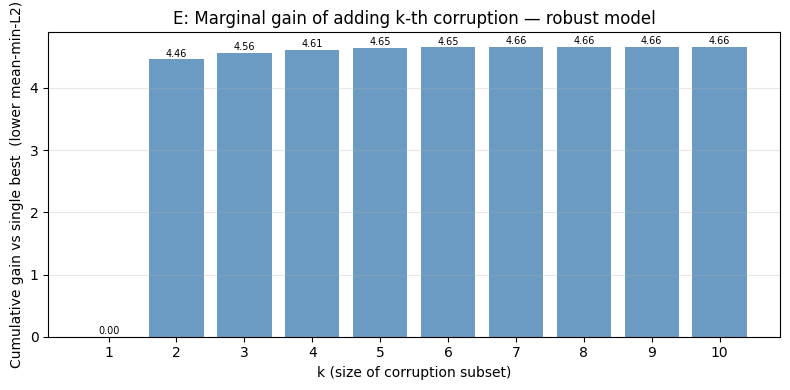

Saved outputs/study5_corruptions/E_marginal_gain_robust.png


In [15]:
import itertools

PENALTY = 30.0   # L2 penalty for immune images (beyond any real boundary distance)
n       = len(CORRUPTION_NAMES)
snames  = [SHORT_NAMES[c] for c in CORRUPTION_NAMES]

for mname in ['standard', 'robust']:
    sub = runs_df[runs_df.model == mname]

    # mat_pen[img_idx, j] = init_l2 for corruption j, or PENALTY if immune/failed
    mat_pen = np.full((N_IMG, n), PENALTY, dtype=np.float64)
    for j, cname in enumerate(CORRUPTION_NAMES):
        for img_idx in range(N_IMG):
            rows = sub[(sub.image_idx == img_idx) & (sub.corruption == cname)]
            if len(rows) == 0:
                continue
            r = rows.iloc[0]
            if r['success'] and not np.isnan(r['init_l2']):
                mat_pen[img_idx, j] = float(r['init_l2'])

    # ── Pair matrix: mean over images of min(L2_A, L2_B) ─────────────────────
    pair_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            pair_mat[i, j] = float(np.mean(np.minimum(mat_pen[:, i], mat_pen[:, j])))

    fig, axes = plt.subplots(1, 1, figsize=(8, 7))
    im = axes.imshow(pair_mat, cmap='RdYlGn_r', aspect='auto')
    axes.set_xticks(range(n)); axes.set_xticklabels(snames, rotation=45, ha='right', fontsize=8)
    axes.set_yticks(range(n)); axes.set_yticklabels(snames, fontsize=8)
    for i in range(n):
        for j in range(n):
            axes.text(j, i, f'{pair_mat[i,j]:.2f}',
                      ha='center', va='center', fontsize=6.5,
                      color='white' if pair_mat[i,j] > pair_mat.max()*0.7 else 'black')
    plt.colorbar(im, ax=axes, label='mean over images of min(L2_A, L2_B)  [lower = better pair]')
    axes.set_title(f'E: Pair quality matrix — {mname} model\n'
                   'Cell (A,B) = mean(min(L2_A, L2_B)) over all images\n'
                   'Diagonal = single-corruption quality  |  lower = better', fontsize=9)
    plt.tight_layout()
    fname = f'{OUTPUT_DIR}/E_pair_matrix_{mname}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

    # ── Marginal gain: exhaustive search over all C(n,k) subsets ─────────────
    best_per_k = {}
    for k in range(1, n + 1):
        best_score = float('inf')
        best_combo = None
        for combo in itertools.combinations(range(n), k):
            s = float(np.mean(np.min(mat_pen[:, list(combo)], axis=1)))
            if s < best_score:
                best_score = s
                best_combo = combo
        best_per_k[k] = (best_score, [CORRUPTION_NAMES[i] for i in best_combo])
        print(f'  {mname} k={k}: score={best_score:.3f}  best={[SHORT_NAMES[c] for c in best_per_k[k][1]]}')

    # Marginal gain = reduction in mean-min-L2 vs previous best set
    marginal = [best_per_k[1][0] - best_per_k[k][0] for k in range(1, n + 1)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(1, n + 1), marginal, color='steelblue', alpha=0.8)
    ax.set_xlabel('k (size of corruption subset)')
    ax.set_ylabel('Cumulative gain vs single best  (lower mean-min-L2)')
    ax.set_title(f'E: Marginal gain of adding k-th corruption — {mname} model')
    ax.set_xticks(range(1, n + 1))
    ax.grid(axis='y', alpha=0.3)
    for k in range(1, n + 1):
        ax.text(k, marginal[k-1] + 0.01, f'{marginal[k-1]:.2f}',
                ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    fname = f'{OUTPUT_DIR}/E_marginal_gain_{mname}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


**Analysis E — ensemble quality: pair matrix and marginal gain.**

**Metric:** for a set S of corruption types, the ensemble score is
`mean over images of min_{c in S}(init_l2_c)` where immune images contribute PENALTY=30.
Lower score = better set (on average, some corruption in S gets close to the boundary).

**Pair matrix (diagonal = single quality, off-diagonal = best pair):**
- The diagonal is identical to the single-corruption unconditional mean from Analysis A.
- Off-diagonal cell (A, B) shows how much gain we get by combining A and B:
  for each image we take the better of the two, then average.

**Marginal gain curve:**
- k=1 → best single corruption
- k=2 → adding the most complementary second corruption; largest jump
- k=3..5 → diminishing returns
- k≥7 → zero marginal gain (the remaining corruptions always lose to something already in the set)

The **elbow at k=2** means the first pair captures most of the gain from ensemble diversity.

*(fill in specific corruption names and scores after run)*


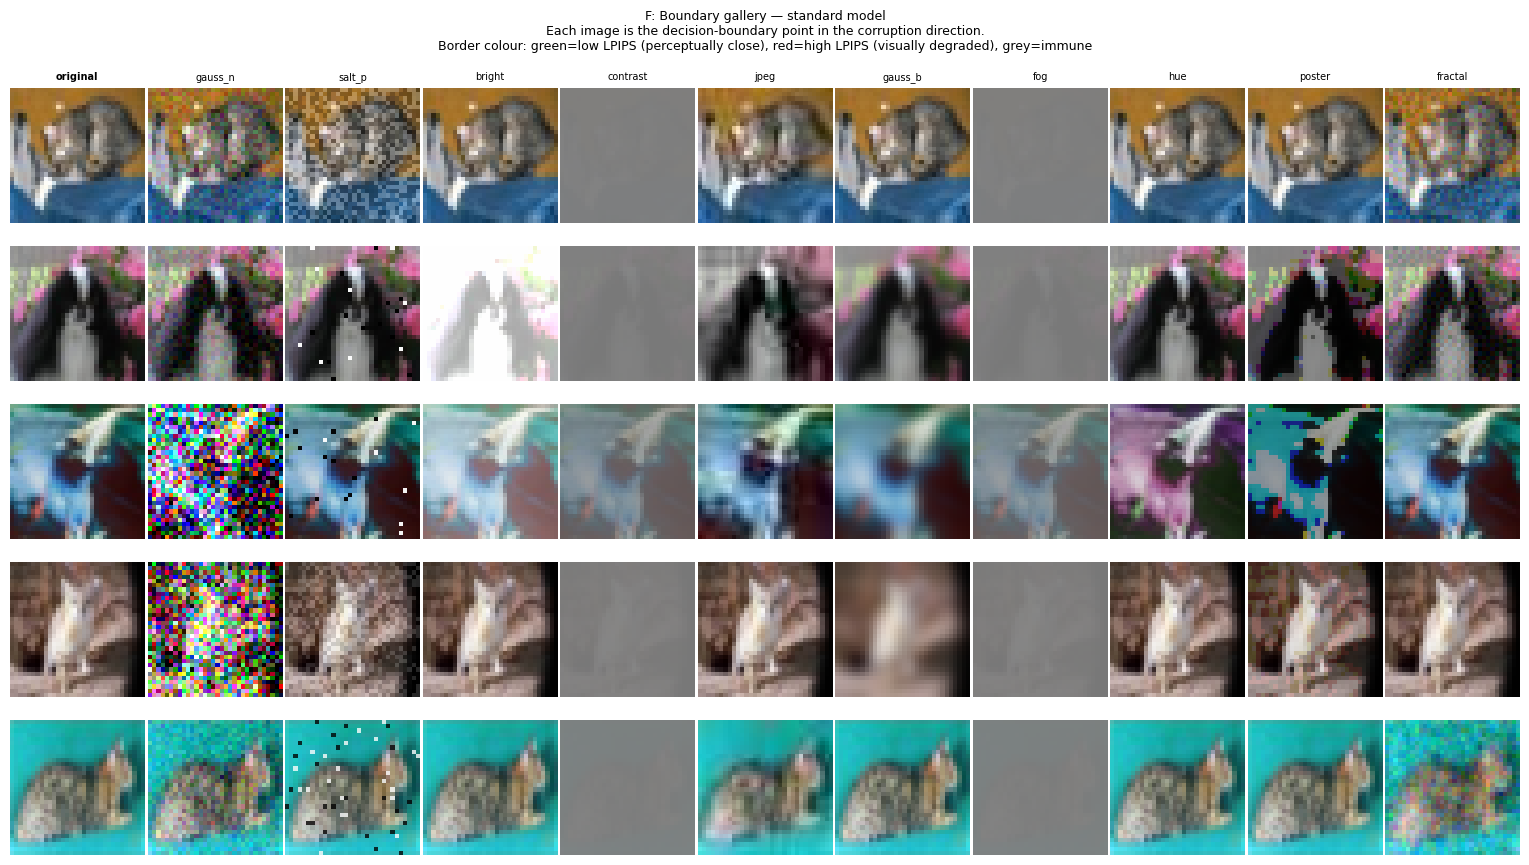

Saved outputs/study5_corruptions/F_gallery_standard.png


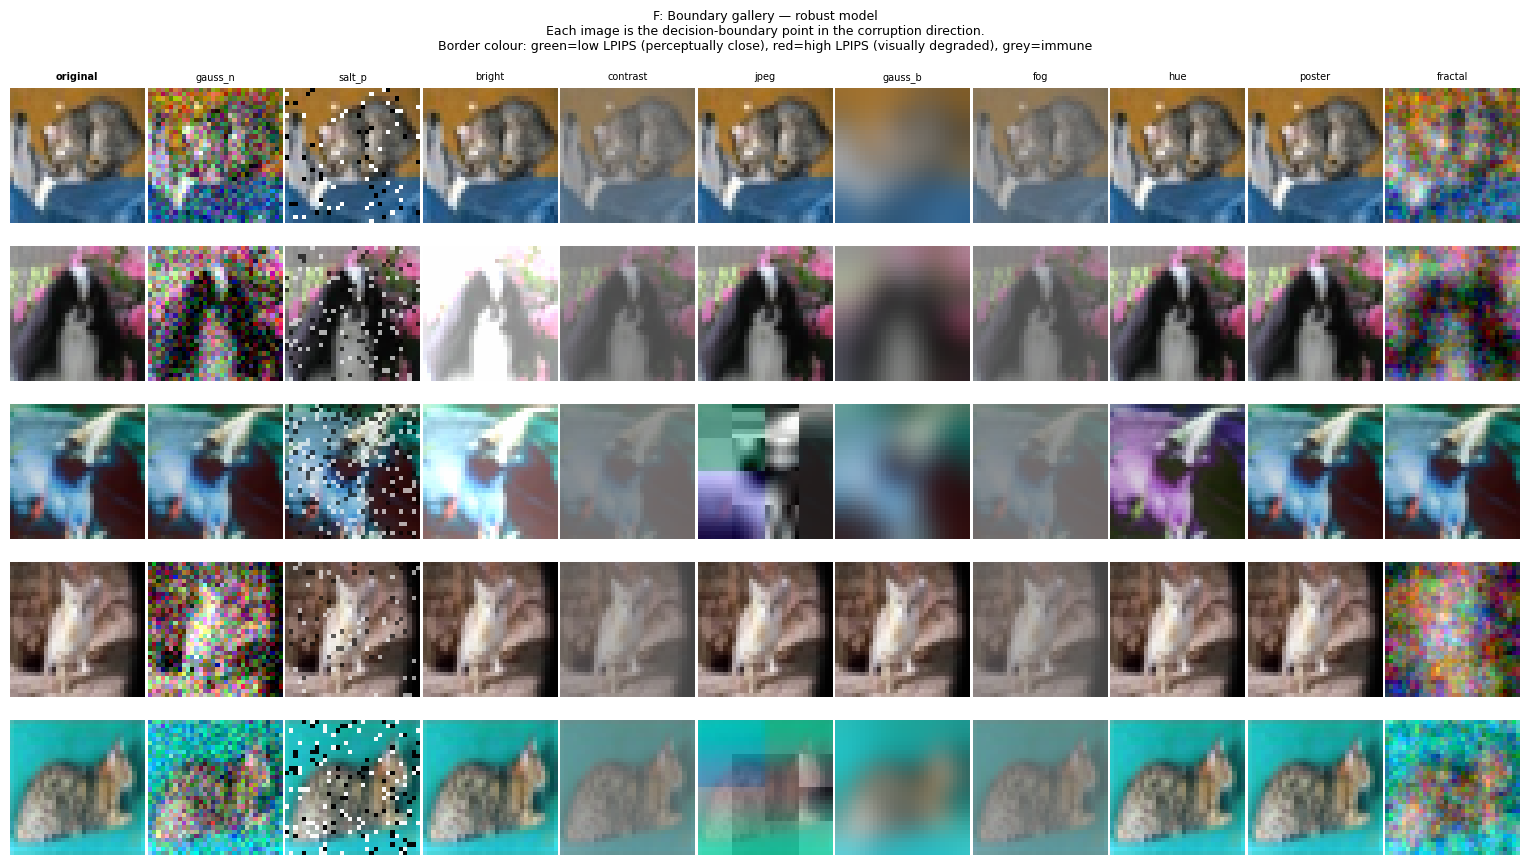

Saved outputs/study5_corruptions/F_gallery_robust.png


In [16]:
def lpips_color(v):
    """Green (low LPIPS=0) -> Yellow -> Red (high LPIPS>=0.3). Falls back to grey if nan."""
    if np.isnan(v):
        return (0.7, 0.7, 0.7)
    norm = min(1.0, v / 0.3)
    return (min(1.0, 2 * norm), min(1.0, 2 * (1.0 - norm)), 0.0)

for mname in ['standard', 'robust']:
    sub = runs_df[runs_df.model == mname].set_index(['image_idx', 'corruption'])

    ncols = 1 + len(CORRUPTION_NAMES)
    nrows = len(GALLERY_IDS)
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 1.4, nrows * 1.8))

    for row, gid in enumerate(GALLERY_IDS):
        x_orig = images[gid]
        y_true = int(labels[gid])

        # Original image column
        ax = axes[row, 0]
        ax.imshow(x_orig.transpose(1, 2, 0).clip(0, 1))
        ax.axis('off')
        if row == 0:
            ax.set_title('original', fontsize=7, fontweight='bold')
        ax.set_ylabel(CIFAR_CLASSES[y_true], fontsize=7, rotation=0,
                      labelpad=30, va='center')

        # Boundary image per corruption
        for col, cname in enumerate(CORRUPTION_NAMES):
            ax = axes[row, col + 1]
            key = (gid, cname)
            if key in sub.index:
                r_row     = sub.loc[key]
                success   = bool(r_row['success'])
                l2_val    = float(r_row['init_l2'])    if success else float('nan')
                ssim_val  = float(r_row['init_ssim'])  if success else float('nan')
                lpips_val = float(r_row['init_lpips']) if (success and 'init_lpips' in r_row.index) else float('nan')
                x_show    = boundaries_arr[int(r_row['row_id'])].transpose(1, 2, 0).clip(0, 1)
            else:
                success   = False
                l2_val    = float('nan'); ssim_val = float('nan'); lpips_val = float('nan')
                x_show    = np.full((32, 32, 3), 0.5)

            ax.imshow(x_show)
            ax.axis('off')
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_edgecolor(lpips_color(lpips_val))
                sp.set_linewidth(3.0)

            if row == 0:
                ax.set_title(SHORT_NAMES[cname], fontsize=7)
            if success:
                lp_str = f'\nP={lpips_val:.3f}' if not np.isnan(lpips_val) else ''
                lbl = f'L2={l2_val:.2f}\nS={ssim_val:.2f}{lp_str}'
            else:
                lbl = 'immune'
            ax.set_xlabel(lbl, fontsize=5.5, labelpad=1,
                          color='black' if success else 'gray')

    plt.suptitle(
        f'F: Boundary gallery — {mname} model\n'
        'Each image is the decision-boundary point in the corruption direction.\n'
        'Border colour: green=low LPIPS (perceptually close), red=high LPIPS (visually degraded), grey=immune',
        fontsize=9)
    plt.tight_layout(h_pad=0.6, w_pad=0.2)
    fname = f'{OUTPUT_DIR}/F_gallery_{mname}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


## Summary & Conclusions

*(fill in after run)*

---

## Section H — Alternative philosophy: label-preserving corruptions

All previous analyses evaluated corruptions *after the fact* — measuring L2, SSIM or LPIPS
at the boundary point found by the binary search.
Here we take the opposite direction: **choose corruption types *a priori*, based on
whether they preserve the human-perceived label throughout the severity range.**

### The argument

A corruption is "philosophically justified" for Phase-1 initialisation if:

1. **At any severity s, a human looking at corrupt(x, s) would still say "that is a [class]".**
   The corruption changes *style* but not *identity*.
2. **Somewhere in [0, 1] the model disagrees** — it misclassifies the image even though a human would not.
   The boundary point at s* is therefore a genuine *model failure*: the image is still semantically valid
   but the model is fooled.

Under this view the adversarial example found by Phase 1 is not just close to the original in pixel space —
it is *semantically equivalent* to the original from a human perspective.
This makes it a stronger attack and a more meaningful robustness test.

### Taxonomy by human label preservation

The key question is: as we increase severity from 0 to 1, at what point does **a human** stop
recognising the correct class? We can reason about this from first principles for each corruption.

| Corruption | What changes | What is preserved | Human label boundary |
|---|---|---|---|
| **hue_shift** | Hue channel only | Luminance, shape, texture, depth cues — everything that carries object identity | Very late or never: a 180° hue-shifted dog is still unmistakably a dog |
| **contrast_low** (fixed) | Pixel values compressed toward their mean | Spatial structure, edges, relative contrasts | Late: a low-contrast image is like a faded photo — object fully recognisable |
| **fog** | Global additive white veil | Spatial structure visible underneath | Late: even dense fog preserves object outlines |
| **brightness** | Additive offset to all pixels | Shape and structure — until clipping dominates | Moderately late: recognisable until most pixels saturate to white |
| **jpeg** | High-frequency energy quantised into DCT blocks | Coarse spatial structure, large-scale edges | Very late: JPEG was engineered to preserve perceived image content |
| **posterize** | Colour quantised to 2^bits levels | Shape, edges; colours become flat-filled regions | Moderately late: at 2-3 bits the image looks like a cartoon but the object is clear |
| **gaussian_blur** | High-frequency detail smoothed | Low-frequency envelope, large structures | Moderately early: at σ≥2–3 on 32×32 px, fine detail is gone; coarse shape remains |
| **gaussian_noise** | All pixels perturbed by i.i.d. Gaussian | Global structure visible through noise (human vision integrates well) | Early: humans start struggling around σ≈0.3–0.4 on [0,1] images |
| **salt_pepper** | Random pixels set to 0 or 1 | Surviving pixels unaffected | Early–moderate: salient white/black specks are visible immediately; object still legible at moderate density |
| **fractal_blend** | Frequency spectrum blended with fractal | Original image content at low blend ratio | Moderate: at ≥50% blend the original is visually dominated by the fractal texture |

### The core argument

Under this philosophy the corruptions split into two groups:

**Group A — semantic-style corruptions** (hue_shift, contrast_low, fog, brightness, jpeg, posterize):
These change the *appearance style* without touching the *semantic content* of the scene.
A human's label decision is driven almost entirely by shape, edges and texture — all of which these
corruptions leave intact until very high severity. The adversarial boundary, wherever it falls, should
therefore lie in a region where the image is still semantically valid.

**Group B — content-corrupting corruptions** (gaussian_noise, salt_pepper, fractal_blend, gaussian_blur):
These directly interfere with the pixel-level information that encodes the object.
A human's recognition degrades early. However, a crucial asymmetry exists:
**models are far more sensitive to these corruptions than humans are at low severity.**
gaussian_noise fools a standard ResNet at σ≈0.05 (nearly imperceptible to humans),
and salt_pepper does the same at only ≈3.5% pixel coverage.
If s* is tiny, the boundary image is effectively still a clean image from the human's perspective,
even though the model has already failed — which satisfies the spirit of the philosophy.

### Which group is better for Phase 1?

The analysis reveals a tension:

- **Group A** is label-preserving *in principle*, but many of these corruptions need a very high
  severity to cross the model's decision boundary. Brightness needs s* ≈ 0.65 (overexposed, barely
  recognisable), contrast/fog need s* ≈ 0.86 (near-flat grey). The model boundary falls late in the
  severity range, by which point human perception has also degraded.

- **Group B** produces semantically valid boundary images *in practice*, because s* is so small
  that the image is barely touched when the model first fails. gaussian_noise at s*=0.047
  and fractal_blend at s*=0.34 produce boundary images that a human would classify with full
  confidence — they just happen to fool the model.

**Recommended selection criterion (heuristic):**
> Choose corruptions for which s* is small relative to the human perceptual threshold.
> Equivalently: choose corruptions where the model is *disproportionately sensitive* compared to humans.

This is a known property of standard (non-robust) models: they rely on high-frequency texture
statistics that humans largely ignore. Gaussian noise directly attacks this weakness.
Robust models (trained with adversarial augmentation) are partially corrected toward human
perception, which is why they require much higher s* for the same corruptions —
and why Group A corruptions become relatively more useful on the robust model.

### Recommended corruption set under this philosophy

| Priority | Corruption | Justification |
|---|---|---|
| 1 | **fractal_blend** | Low s*, boundary image near-pristine, LPIPS at boundary ≈ 0.004. Attacks model's frequency-domain sensitivity. |
| 2 | **gaussian_noise** | Lowest s* of all (≈0.047), boundary image essentially untouched. Classic model-vs-human sensitivity gap. |
| 3 | **jpeg** | Semantically designed to preserve perceived content; still fools standard model at moderate compression. |
| 4 | **posterize** | Style-only corruption; boundary LPIPS low; label preserved until extreme quantisation. |
| 5 | **hue_shift** | Purest semantic-style corruption (color only); high immune rate limits usefulness, but when it works the boundary is always recognisable. |

brightness, contrast_low, and fog are the *worst* choices under this philosophy despite being
the most intuitively "safe" — the model boundary consistently falls in the perceptually degraded zone.
